# 03 - Modelagem Preditiva

Compara tres modelos para prever `SeriousDlqin2yrs` (inadimplencia): Regressao Logistica (baseline), Random Forest e LightGBM.

Cada modelo roda dentro de um pipeline que faz, na ordem: pre-processamento (imputacao/winsorizacao, ajustado somente no treino) -> SMOTE (balanceamento, somente no treino) -> classificador. Ver `src/features.py` e `src/train.py`.

## Setup

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.train import split_data, train_and_compare, save_model
from src.evaluate import (
    get_confusion_matrix,
    get_roc_curve,
    find_ks_optimal_threshold,
    metrics_at_threshold,
    get_precision_recall_curve,
)

sns.set_theme(style="whitegrid")


## Carregar dataset com atributos derivados

In [2]:
df = pd.read_csv("../data/processed/credit_features.csv")
print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
df["SeriousDlqin2yrs"].value_counts(normalize=True)


Linhas: 149,999 | Colunas: 18


SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

## Split treino/teste (estratificado)

In [3]:
X_train, X_test, y_train, y_test = split_data(df)

print(f"Treino: {X_train.shape[0]:,} linhas | Teste: {X_test.shape[0]:,} linhas")
print(f"Taxa de inadimplencia - treino: {y_train.mean():.2%} | teste: {y_test.mean():.2%}")


Treino: 119,999 linhas | Teste: 30,000 linhas
Taxa de inadimplencia - treino: 6.68% | teste: 6.68%


## Treinar e comparar os modelos

O SMOTE roda **dentro** do pipeline de cada modelo, ajustado apenas em `X_train` a cada fit — o conjunto de teste nunca e balanceado artificialmente, para que as metricas reflitam a distribuicao real do problema.

In [4]:
results = train_and_compare(X_train, y_train, X_test, y_test)


d:\Projetos\Portfolio\Credit Risk Analytics\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logistic_regression: {'auc_roc': 0.8613, 'ks': 0.5761, 'recall': 0.7541, 'precision': 0.2248}
random_forest: {'auc_roc': 0.8602, 'ks': 0.5662, 'recall': 0.3761, 'precision': 0.4351}
lightgbm: {'auc_roc': 0.8627, 'ks': 0.5795, 'recall': 0.2125, 'precision': 0.5266}


## Tabela comparativa de metricas

In [5]:
comparison = pd.DataFrame({name: r["metrics"] for name, r in results.items()}).T
comparison = comparison.sort_values("auc_roc", ascending=False)
comparison


,auc_roc,ks,recall,precision
lightgbm,0.8627,0.5795,0.2125,0.5266
logistic_regression,0.8613,0.5761,0.7541,0.2248
random_forest,0.8602,0.5662,0.3761,0.4351


**Nota:** repare que o recall/precisao aqui sao calculados no threshold padrao de 0.5 — e por isso que a Regressao Logistica pode aparecer com recall bem mais alto que o LightGBM, mesmo tendo AUC-ROC/KS piores. Isso e explorado na proxima secao.

## Curvas ROC

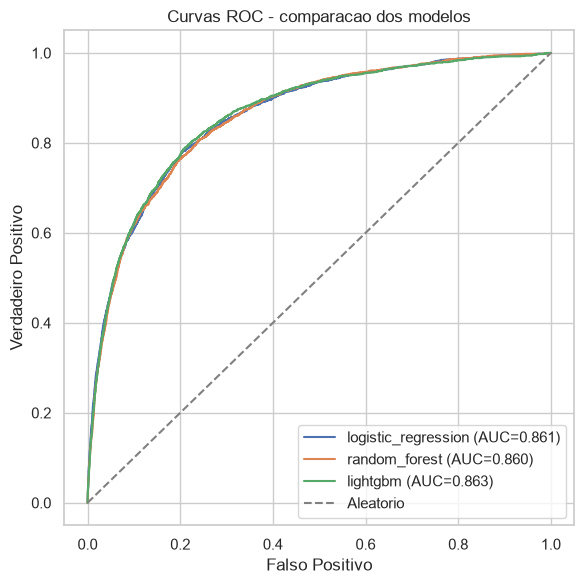

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, r in results.items():
    fpr, tpr, _ = get_roc_curve(y_test, r["y_pred_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['metrics']['auc_roc']:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")
ax.set_xlabel("Falso Positivo")
ax.set_ylabel("Verdadeiro Positivo")
ax.set_title("Curvas ROC - comparacao dos modelos")
ax.legend()
plt.tight_layout()
plt.show()


## Matriz de confusao do melhor modelo (threshold padrao 0.5)

Melhor modelo por AUC-ROC: lightgbm


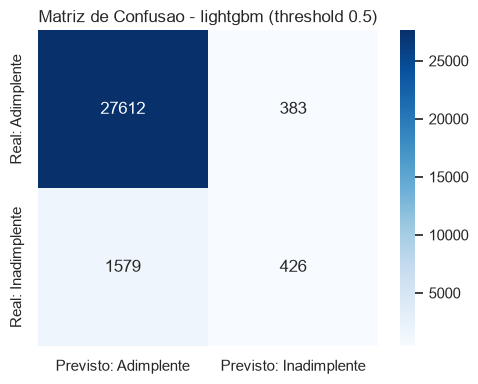

In [7]:
best_name = comparison.index[0]
print(f"Melhor modelo por AUC-ROC: {best_name}")

cm = get_confusion_matrix(y_test, results[best_name]["y_pred_proba"])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Previsto: Adimplente", "Previsto: Inadimplente"],
            yticklabels=["Real: Adimplente", "Real: Inadimplente"], ax=ax)
ax.set_title(f"Matriz de Confusao - {best_name} (threshold 0.5)")
plt.tight_layout()
plt.show()


## Ajuste do ponto de corte (threshold)

AUC-ROC e KS avaliam a capacidade do modelo de **ordenar** clientes do mais ao menos arriscado, independente de onde "cortamos" a probabilidade em sim/nao. Mas para uso no negocio, precisamos escolher um ponto de corte — e o 0.5 usado ate aqui e arbitrario, nao e uma decisao de negocio.

Uma abordagem comum no mercado de credito e usar o **ponto de corte que maximiza o KS** (a maior distancia entre as curvas cumulativas de bons e maus pagadores) como referencia inicial, e depois ajustar conforme o apetite de risco da area de negocio.

In [8]:
ks_threshold = find_ks_optimal_threshold(y_test, results[best_name]["y_pred_proba"])
print(f"Threshold padrao: 0.5")
print(f"Threshold otimo (maximiza KS) para {best_name}: {ks_threshold:.4f}")

comparison_thresholds = pd.DataFrame(
    [
        metrics_at_threshold(y_test, results[best_name]["y_pred_proba"], 0.5),
        metrics_at_threshold(y_test, results[best_name]["y_pred_proba"], ks_threshold),
    ],
    index=["Threshold padrao (0.5)", "Threshold otimo (KS)"],
)
comparison_thresholds


Threshold padrao: 0.5
Threshold otimo (maximiza KS) para lightgbm: 0.0759


,threshold,recall,precision,f1
Threshold padrao (0.5),0.5000,0.2125,0.5266,0.3028
Threshold otimo (KS),0.0759,0.7875,0.2133,0.3357


**Nota:** repare como recall e precisao mudam ao trocar o ponto de corte — esse e exatamente o trade-off que uma area de negocio decide na pratica: quantos inadimplentes aceito deixar passar (recall) em troca de aprovar mais clientes bons (precisao)? O threshold ideal depende do apetite de risco e do custo de cada tipo de erro, nao so da metrica do modelo.

## Curva Precisao-Recall (trade-off completo)

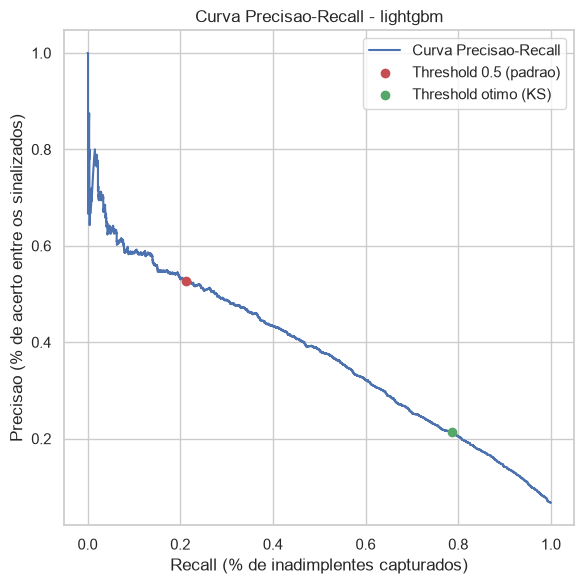

In [9]:
precision_vals, recall_vals, _ = get_precision_recall_curve(y_test, results[best_name]["y_pred_proba"])

m_default = metrics_at_threshold(y_test, results[best_name]["y_pred_proba"], 0.5)
m_ks = metrics_at_threshold(y_test, results[best_name]["y_pred_proba"], ks_threshold)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(recall_vals, precision_vals, color="#4C72B0", label="Curva Precisao-Recall")
ax.scatter([m_default["recall"]], [m_default["precision"]], color="#C44E52",
           zorder=5, label="Threshold 0.5 (padrao)")
ax.scatter([m_ks["recall"]], [m_ks["precision"]], color="#55A868",
           zorder=5, label="Threshold otimo (KS)")
ax.set_xlabel("Recall (% de inadimplentes capturados)")
ax.set_ylabel("Precisao (% de acerto entre os sinalizados)")
ax.set_title(f"Curva Precisao-Recall - {best_name}")
ax.legend()
plt.tight_layout()
plt.show()


## Matriz de confusao no threshold otimo (KS)

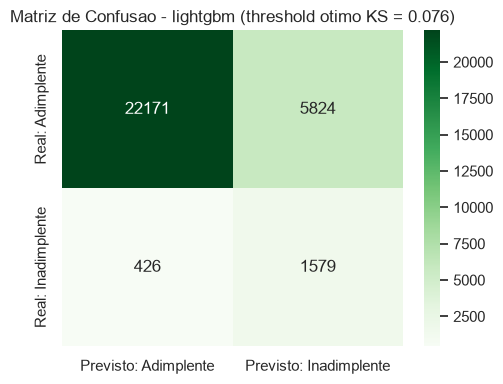

In [10]:
cm_ks = get_confusion_matrix(y_test, results[best_name]["y_pred_proba"], threshold=ks_threshold)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_ks, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Previsto: Adimplente", "Previsto: Inadimplente"],
            yticklabels=["Real: Adimplente", "Real: Inadimplente"], ax=ax)
ax.set_title(f"Matriz de Confusao - {best_name} (threshold otimo KS = {ks_threshold:.3f})")
plt.tight_layout()
plt.show()


## Salvar o melhor modelo

In [11]:
model_path = save_model(results[best_name]["pipeline"], best_name)
print(f"Modelo salvo em {model_path}")
print(f"Threshold de negocio recomendado (otimo KS): {ks_threshold:.4f}")


Modelo salvo em D:\Projetos\Portfolio\Credit Risk Analytics\models\lightgbm.joblib
Threshold de negocio recomendado (otimo KS): 0.0759


## Conclusoes

- Comparados 3 modelos (Regressao Logistica, Random Forest, LightGBM) com pipeline sem vazamento de dados (pre-processamento e SMOTE ajustados somente no treino).
- LightGBM venceu em AUC-ROC e KS — as metricas corretas para comparar modelos, pois independem do ponto de corte escolhido.
- Adicionada analise de threshold: o ponto de corte otimo por KS muda bastante o recall/precisao em relacao ao 0.5 padrao, evidenciando que a escolha do threshold e uma decisao de negocio, nao so uma saida do modelo.
- Melhor modelo e o threshold de negocio recomendado salvos/documentados.
- Proximo passo: `04_explicabilidade_shap.ipynb`, para entender quais variaveis mais pesam nas decisoes do modelo escolhido.